In [7]:
# @title Install dependencies
%pip install nilearn 

Note: you may need to restart the kernel to use updated packages.


In [8]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from nilearn import plotting

In [9]:
# The download cells will store the data in nested directories starting here:
DATA_DIR = "./hcp_retino"
if not os.path.isdir(DATA_DIR):
  os.mkdir(DATA_DIR)

# The data acquisition rate
TR = 1  # Time resolution, in sec

# Time series data are organized by experiment, with each experiment
# having an LR and RL (phase-encode direction) acquisition
RUN_NAMES = [
  "BAR1",   # Sweeping Bars repeat 1
  "BAR2",   # Sweeping Bars repeat 2
  "CCW",    # Counter Clockwise rotating wedge
  "CW",     # Clockwise rotating wedge
  "EXP",    # Expanding ring
  "CON"     # Contracting ring
]

In [10]:
# @title Download the data

import os, requests, tarfile
fname = "hcp_retino.tgz"
url = "https://osf.io/d25b4/download"

if not os.path.isfile(fname):
  try:
    r = requests.get(url)
  except requests.ConnectionError:
    print("!!! Failed to download data !!!")
  else:
    if r.status_code != requests.codes.ok:
      print("!!! Failed to download data !!!")
    else:
      print(f"Downloading {fname}...")
      with open(fname, "wb") as fid:
        fid.write(r.content)
      print(f"Download {fname} completed!")

Download hcp_retino.tgz completed!


In [11]:
# @title Extract the data in `DATA_DIR`
fname_ex = "HCP7T_retino"
path_name = os.path.join(DATA_DIR, fname_ex)
if not os.path.exists(path_name):
  print(f"Extracting {fname}...")
  with tarfile.open(f"{fname}") as fzip:
    fzip.extractall(DATA_DIR)
else:
  print(f"File {fname}.tgz has already been extracted.")

Extracting hcp_retino.tgz...


In [12]:
retino_dir = os.path.join(DATA_DIR, "HCP7T_retino")
for root, dirs, files in os.walk(retino_dir):
    for file in files:
        print(os.path.join(root, file))

./hcp_retino/HCP7T_retino/tfMRI_RETBAR1_7T_AP.dtseries.nii
./hcp_retino/HCP7T_retino/tfMRI_RETEXP_7T_AP.dtseries.nii
./hcp_retino/HCP7T_retino/tfMRI_RETCCW_7T_AP.dtseries.nii
./hcp_retino/HCP7T_retino/tfMRI_RETCON_7T_PA.dtseries.nii
./hcp_retino/HCP7T_retino/tfMRI_RETBAR2_7T_PA.dtseries.nii
./hcp_retino/HCP7T_retino/tfMRI_RETCW_7T_PA.dtseries.nii
./hcp_retino/HCP7T_retino/surf/Q1-Q6_R440.MyelinMap_BC.32k_fs_LR.dscalar.nii
./hcp_retino/HCP7T_retino/surf/Q1-Q6_R440.R.white.32k_fs_LR.surf.gii
./hcp_retino/HCP7T_retino/surf/Q1-Q6_R440.R.very_inflated.32k_fs_LR.surf.gii
./hcp_retino/HCP7T_retino/surf/Q1-Q6_R440.R.inflated.32k_fs_LR.surf.gii
./hcp_retino/HCP7T_retino/surf/Q1-Q6_R440.R.pial.32k_fs_LR.surf.gii
./hcp_retino/HCP7T_retino/surf/Q1-Q6_R440.L.sphere.32k_fs_LR.surf.gii
./hcp_retino/HCP7T_retino/surf/Q1-Q6_R440.L.midthickness.32k_fs_LR.surf.gii
./hcp_retino/HCP7T_retino/surf/Q1-Q6_R440.L.inflated.32k_fs_LR.surf.gii
./hcp_retino/HCP7T_retino/surf/Q1-Q6_R440.R.midthickness.32k_fs_LR.sur

In [13]:
# Path to one of the runs (you can switch to other ones)
fmri_file = "./hcp_retino/HCP7T_retino/tfMRI_RETBAR1_7T_AP.dtseries.nii"

# Load the file
img = nib.load(fmri_file)
data = img.get_fdata()

print("Shape of fMRI data:", data.shape)

Shape of fMRI data: (300, 91282)


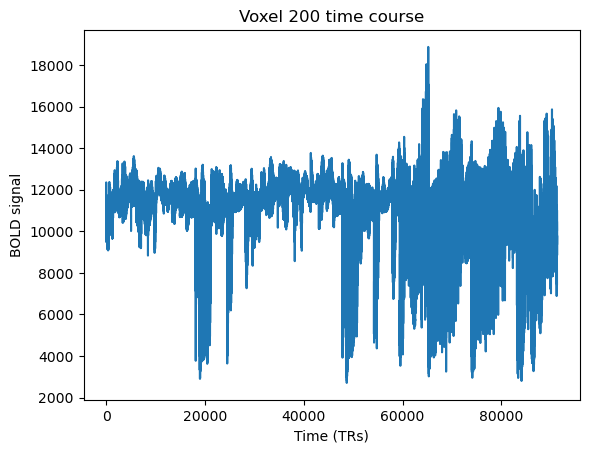

In [16]:
# Pick a grayordinate (e.g., 10000 = left V1 area)
grayordinate_idx = 200
timecourse = data[grayordinate_idx, :]

import matplotlib.pyplot as plt

plt.plot(timecourse)
plt.xlabel("Time (TRs)")
plt.ylabel("BOLD signal")
plt.title(f"Voxel {grayordinate_idx} time course")
plt.show()

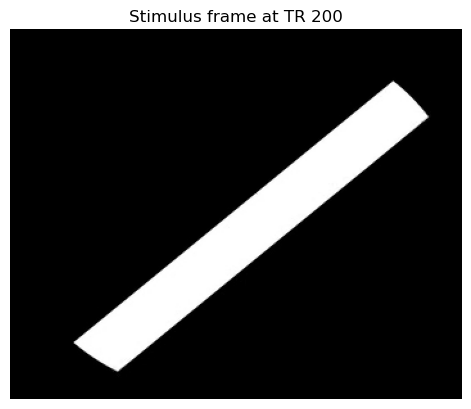

In [20]:
frame_idx = 200  # Any number between 0 and 299
frame = stim[frame_idx]

plt.imshow(frame)
plt.title(f"Stimulus frame at TR {frame_idx}")
plt.axis("off")
plt.show()